# Purpose of This Notebook

There are two issues that require revision:

**1. Recalculate the Buffer Range**

In the original `00_prepare_model_dataset.ipynb`, the calculation of nearby facilities (bike stations, subway stations) used two methods:

1. Counting the number of facilities within each grid.
2.	Applying a 1000-meter buffer from the grid centroid to capture nearby facilities.


However, according to established literature on Transit-Oriented Development (TOD) and human walkability, the commonly referenced distances are 400m, 800m, and 1100m, representing the core, secondary, and edge zones of walkability. This notebook revises the previous calculations to align with these standards.

Since the grid size is 250m and calculations are based on the grid centroid, an adjustment is necessary to account for the spatial uncertainty between the centroid and the grid boundaries. To ensure adequate coverage, the buffer distances are adjusted to 500m, 900m, and 1200m, which correspond to the intended 400m, 800m, and 1100m thresholds.

**2. Reload the Holiday Dataset**

It was also found that the original holiday dataset only contains data after 2025 and was previously misinterpreted—the end date was incorrectly treated as inclusive. The revised dataset, `combined_ny_holidays.csv`, is located under `data/data_preparation/holiday_module/Holiday`.

This notebook will therefore:
1. Recalculate the number of bike and subway stations within the revised buffer zones for future modeling.
2. Reload the corrected holiday dataset from the updated source.


# Setting

## Import packages

In [1]:
# === System & Utility ===
import os
import glob
import re
import time
import json
import math
import itertools
from dotenv import load_dotenv
import requests

# === Data Handling ===
import pandas as pd
import numpy as np
import geopandas as gpd

# === Geospatial & Location ===
import osmnx as ox
from shapely.geometry import Point
from shapely.wkt import dumps, loads
from geopy.geocoders import Nominatim

# === Visualization ===
import matplotlib.pyplot as plt
import seaborn as sns
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors
from matplotlib.cm import ScalarMappable
from matplotlib.colors import Normalize

# === Statistical Tools ===
from scipy import stats
from scipy.stats import norm, chi2_contingency, pointbiserialr

# === Preprocessing & Dimensionality Reduction ===
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split

# === Evaluation Metrics ===
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    confusion_matrix, classification_report, make_scorer, roc_auc_score
)

# === Classification Models ===
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
from sklearn.linear_model import LogisticRegression, SGDClassifier
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier

# === Regression Models ===
from sklearn.linear_model import LinearRegression, Ridge, Lasso, SGDRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from lightgbm import LGBMRegressor
from xgboost import XGBRegressor
from catboost import CatBoostRegressor

# === Display Settings ===
pd.set_option('display.precision', 4)

## Self-defined functions

### check_table_info

In [69]:
def check_table_info(target_df):
    """
    To check the unique values, dtype, example, missing rate of each column
    """
    table_info = []
    for col in target_df:
        table_info_row = []
        table_info_row.append(col)
        table_info_row.append(target_df[col].nunique())
        table_info_row.append(target_df[col].dtype)
        table_info_row.append(target_df[col].iloc[0])
        table_info_row.append(round(target_df[col].isna().sum() / target_df.shape[0]*100,2))

        table_info.append(table_info_row)
    res = pd.DataFrame(table_info, columns=['col_name', 'unique_values', 'dtype', 'example', 'missing%'])

    return res

### load_geoDataFrame

In [3]:
def load_geoDataFrame(filepath):
    """
    Load a GeoDataFrame from a CSV file with a geometry column in WKT format.

    Parameters:
        filepath (str): Path to the CSV file containing the saved GeoDataFrame.

    Returns:
        GeoDataFrame: A GeoDataFrame reconstructed from the CSV, with geometries parsed from WKT strings.
    
    Notes:
        - Assumes the geometry column is named 'geometry' and stored in WKT format.
        - The returned GeoDataFrame is assigned the CRS 'EPSG:4326' by default.
    """
    df = pd.read_csv(filepath)
    df['geometry'] = df['geometry'].apply(loads)
    return gpd.GeoDataFrame(df, geometry='geometry', crs="EPSG:4326")

### gen_point_area_buffer_mapping

In [4]:
def gen_point_area_buffer_mapping(point_df, lat_col, lon_col, grid_df, grid_id_col='grid_id', buffer_radius_m=1000):
    """
    Maps each point in point_df to a nearby grid cell (from grid_df) using a centroid-based buffer.

    Parameters:
        point_df (pd.DataFrame): DataFrame with point locations, must include latitude and longitude columns.
        lat_col (str): Name of the latitude column in point_df.
        lon_col (str): Name of the longitude column in point_df.
        grid_df (gpd.GeoDataFrame): GeoDataFrame with polygon grid geometries (e.g., Manhattan grid).
        grid_id_col (str): Column in grid_df representing the unique ID of each grid (default: 'grid_id').
        buffer_radius_m (float): Radius in meters to buffer around each grid's centroid (default: 1000 meters).

    Returns:
        gpd.GeoDataFrame: A GeoDataFrame with all points that fall within any grid centroid's buffer,
                          including matched grid IDs.
    """
    # Project grid to a suitable projected CRS (NYC local)
    grid_proj = grid_df.to_crs(epsg=2263)
    grid_proj['centroid'] = grid_proj.geometry.centroid
    grid_proj['buffer'] = grid_proj['centroid'].buffer(buffer_radius_m)

    # Create buffer GeoDataFrame
    buffer_gdf = grid_proj[[grid_id_col, 'buffer']].copy()
    buffer_gdf = buffer_gdf.set_geometry('buffer')
    buffer_gdf = buffer_gdf.set_crs(epsg=2263)

    # Prepare point GeoDataFrame and project to same CRS
    point_df = point_df.dropna(subset=[lat_col, lon_col]).copy()
    point_gdf = gpd.GeoDataFrame(
        point_df,
        geometry=gpd.points_from_xy(point_df[lon_col], point_df[lat_col]),
        crs="EPSG:4326"
    )
    point_proj = point_gdf.to_crs(epsg=2263)

    # Drop potential naming conflict column
    if 'index_right' in point_proj.columns:
        point_proj = point_proj.drop(columns=['index_right'])

    # Spatial join: points within buffer zones
    joined = gpd.sjoin(point_proj, buffer_gdf, how='inner', predicate='within')

    return joined

### calculate_trips_by_buffer

In [5]:
def calculate_trips_by_buffer(
    df, 
    grid_df, 
    prefix,
    lat_col='lat', 
    lon_col='lon', 
    trip_time_col='trip_time', 
    trips_col='trips', 
    grid_id_col='grid_id', 
    buffer_distances=[500, 900, 1200], 
    buffer_labels=['core', 'secondary', 'edge']
):
    """
    General function to calculate trips (bike, subway, etc.) within multiple buffer zones around grids.

    Parameters:
        df (pd.DataFrame): DataFrame containing trip data.
        grid_df (pd.DataFrame): DataFrame containing grid geometry and grid IDs.
        lat_col (str): Latitude column name.
        lon_col (str): Longitude column name.
        trip_time_col (str): Trip time column name.
        trips_col (str): Trips column name.
        grid_id_col (str): Grid ID column name.
        prefix (str): The prefix for output column names (e.g., 'bike', 'subway').
        buffer_distances (list): List of buffer distances in meters.
        buffer_labels (list): Corresponding labels for buffer zones (same order as distances).
        point_area_func (function): Function to calculate buffer mapping (your existing spatial function).

    Returns:
        pd.DataFrame: Merged DataFrame with trips per zone and time.
    """
    assert len(buffer_distances) == len(buffer_labels), "buffer_distances and buffer_labels must be the same length."
    
    prefix = prefix.strip().lower()
    station_points = df[[lat_col, lon_col]].drop_duplicates()

    buffer_dfs = {}
    for dist, label in zip(buffer_distances, buffer_labels):
        buffer_df = gen_point_area_buffer_mapping(
            point_df=station_points,
            lat_col=lat_col,
            lon_col=lon_col,
            grid_df=grid_df[[grid_id_col, 'geometry']],
            grid_id_col=grid_id_col,
            buffer_radius_m=dist
        )
        buffer_dfs[label] = buffer_df

    # Group trips for each zone
    merged = None
    for label in buffer_labels:
        buffer_df = buffer_dfs[label]
        tmp = df.merge(buffer_df[[lat_col, lon_col, grid_id_col]], on=[lat_col, lon_col])
        tmp_grouped = tmp.groupby([trip_time_col, grid_id_col])[trips_col].sum().reset_index()
        tmp_grouped = tmp_grouped.rename(columns={trips_col: f'{prefix}_trips_{label}_zone_cumulative'})
        
        if merged is None:
            merged = tmp_grouped
        else:
            merged = merged.merge(tmp_grouped, on=[trip_time_col, grid_id_col], how='outer').fillna(0)
    
    # Extract date and hour
    merged['date'] = pd.to_datetime(pd.to_datetime(merged[trip_time_col]).dt.date)
    merged['hour'] = pd.to_datetime(merged[trip_time_col]).dt.hour.astype(int)
    
    # Calculate exclusive trips within each zone (non-overlapping rings)
    cumulative_cols = [f'{prefix}_trips_{label}_zone_cumulative' for label in buffer_labels]
    merged[f'{prefix}_trips_{buffer_labels[-1]}_zone'] = merged[cumulative_cols[-1]] - merged[cumulative_cols[-2]]
    merged[f'{prefix}_trips_{buffer_labels[1]}_zone'] = merged[cumulative_cols[1]] - merged[cumulative_cols[0]]
    merged[f'{prefix}_trips_{buffer_labels[0]}_zone'] = merged[cumulative_cols[0]]
    
    # Final column selection
    final_cols = ['date', 'hour', grid_id_col] + \
                 [f'{prefix}_trips_{label}_zone' for label in buffer_labels]
    
    return merged[final_cols]

### convert_percentile_to_level

In [6]:
def convert_percentile_to_level(series):
    """
    Convert continuous percentile values to 5-level categorical bins
    (equal-width binning from min to max).
    """
    min_val = series.min()
    max_val = series.max()
    bins = np.linspace(min_val, max_val, 6)  # 5 bins
    labels = ['1', '2', '3', '4', '5']

    result = pd.cut(
        series,
        bins=bins,
        labels=labels,
        include_lowest=True
    )
    return result

### plot_busyness_percentile_map

In [7]:
def plot_busyness_percentile_map(df, date_str, hour_int, busyness_level, ax=None, figsize=(6, 6), cmap='OrRd'):
    # 1. Filter data for the specified date and hour
    df_hour = df[(df['date'] == date_str) & (df['hour'] == hour_int)].copy()

    # 2. Convert to GeoDataFrame and reproject to Web Mercator
    gdf = gpd.GeoDataFrame(df_hour, geometry='geometry', crs='EPSG:4326').to_crs(epsg=3857)

    # 3. Drop rows with missing percentile values
    gdf = gdf.dropna(subset=[busyness_level])

    # 4. Prepare ax
    if ax is None:
        fig, ax = plt.subplots(figsize=figsize)

    # 5. Plot the heatmap
    gdf.plot(
        ax=ax,
        column=busyness_level,
        cmap=cmap,
        linewidth=0.1,
        edgecolor='white',
        legend=True,
        legend_kwds={'title': busyness_level, 'bbox_to_anchor': (1.05, 1), 'loc': 'upper left'}
    )

    ax.set_title(f"{busyness_level} - {date_str} {hour_int:02d}:00", fontsize=12)
    ax.axis("off")


### classification_evaluation

In [8]:
def classification_evaluation(y_actual, y_pred):
    """
    Prints a full evaluation report for multiclass classification results.

    Shows:
    - Accuracy
    - Precision (macro)
    - Recall (macro)
    - F1 score (macro)
    - Confusion matrix
    - Classification report

    Args:
        y_actual (array-like): True class labels
        y_pred (array-like): Predicted class labels
    """

    print("Accuracy       :", round(accuracy_score(y_actual, y_pred), 3))
    print("Precision Score:", round(precision_score(y_actual, y_pred, average='macro'), 3))
    print("Recall Score   :", round(recall_score(y_actual, y_pred, average='macro'), 3))
    print("F1 Score       :", round(f1_score(y_actual, y_pred, average='macro'), 3))
    print()

    # Confusion Matrix
    cm = confusion_matrix(y_actual, y_pred)
    plt.figure(figsize=(6, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.title('Confusion Matrix')
    plt.show()

    print("\nClassification Report:")
    print(classification_report(y_actual, y_pred, zero_division=1))

### predict_sample_dataset

In [9]:
def predict_sample_dataset(model, input_X, input_y, 
                           sample_size=1000000, 
                           y_type='categorical', 
                           is_lgbm=False, is_cat=False,
                           eval_metric=None):
    """
    Train and evaluate a model on a sampled dataset.

    Parameters:
        model: sklearn, LightGBM, or CatBoost model
        input_X (DataFrame): feature set
        input_y (Series): target
        sample_size (int): max sample size
        y_type (str): 'continuous' or 'categorical'
        is_lgbm (bool): use LGBM-style training
        is_cat (bool): use CatBoost-style training
        eval_metric (str): metric for model evaluation
    """

    if y_type not in ['continuous', 'categorical']:
        raise ValueError('y_type must be "continuous" or "categorical"')

    # Sample
    X_sample = input_X.sample(n=min(sample_size, len(input_X)), random_state=42)
    y_sample = input_y.loc[X_sample.index]

    # Split
    stratify_arg = y_sample if y_type == 'categorical' else None
    X_train, X_test, y_train, y_test = train_test_split(
        X_sample, y_sample, test_size=0.3, stratify=stratify_arg, random_state=42
    )

    cat_features = X_sample.select_dtypes('category').columns.tolist()

    # Fit
    if not is_lgbm and not is_cat:
        model.fit(X_train, y_train)
    elif is_lgbm:
        model.fit(
            X_train, y_train,
            eval_set=[(X_test, y_test)],
            eval_metric=eval_metric,
            categorical_feature=cat_features,
            callbacks=[lgb.early_stopping(10)]
        )
    elif is_cat:
        model.fit(
            X_train, y_train,
            eval_set=(X_test, y_test),
            cat_features=cat_features)

    # Predict
    y_pred = model.predict(X_test)

    # Optional fix for CatBoost regression/classification float output
    if is_cat and y_type == 'categorical' and not np.issubdtype(y_pred.dtype, np.integer):
        y_pred = np.round(y_pred).astype(int)

    # Evaluate
    if y_type == 'continuous':
        y_test_label = convert_percentile_to_level(pd.Series(y_test).reset_index(drop=True))
        y_pred_label = convert_percentile_to_level(pd.Series(y_pred).reset_index(drop=True))
    else:
        y_test_label = y_test
        y_pred_label = y_pred

    classification_evaluation(y_test_label, y_pred_label)

### encode_features

In [10]:
from sklearn.preprocessing import StandardScaler
import pandas as pd

def encode_features(input_df, input_features, drop_first=True):
    """
    Transforms input features for modeling:
    
    - Boolean features are converted to integers (0 or 1).
    - Categorical features (dtype 'category') are one-hot encoded.
        - Optionally drops the first dummy column to avoid multicollinearity.
    - Numerical (continuous) features are standardized using StandardScaler.
    
    Tracks:
    - The original-to-transformed column mappings.
    - Which dummy columns (baseline categories) were dropped.

    Args:
        input_df (pd.DataFrame): Original input DataFrame.
        input_features (list): List of column names to transform.
        drop_first (bool): Whether to drop the first dummy variable for each categorical feature.

    Returns:
        encoded_df (pd.DataFrame): Final encoded DataFrame ready for modeling.
        drop_col_df (pd.DataFrame): Info about dropped dummy columns (if any).
        mapping_df (pd.DataFrame): Mapping from original features to encoded columns.
    """
    encoded_df = pd.DataFrame(index=input_df.index)
    drop_col_records = []
    mapping_records = []

    for feature in input_features:
        series = input_df[feature]

        if series.dtype.name == 'bool':
            # Convert boolean to integer (0/1)
            encoded_df[feature] = series.astype(int)
            mapping_records.append({'original_feature': feature, 'feature': feature})

        elif series.dtype.name == 'category':
            # One-hot encode categorical
            dummies = pd.get_dummies(series, prefix=feature, prefix_sep='_', drop_first=False)

            for dummy_col in dummies.columns:
                mapping_records.append({'original_feature': feature, 'feature': dummy_col})

            if drop_first:
                dropped_col = dummies.columns[0]
                drop_col_records.append({
                    'original_feature': feature,
                    'baseline_category': dropped_col,
                    'true_cases': dummies[dropped_col].sum()
                })
                dummies.drop(columns=[dropped_col], inplace=True)

            encoded_df = pd.concat([encoded_df, dummies], axis=1)

        else:
            # Standardize numeric feature
            scaler = StandardScaler()
            standardized = scaler.fit_transform(series.values.reshape(-1, 1))
            encoded_df[feature] = standardized.flatten()
            mapping_records.append({'original_feature': feature, 'feature': feature})

    drop_col_df = pd.DataFrame(drop_col_records)
    mapping_df = pd.DataFrame(mapping_records)

    return encoded_df, drop_col_df, mapping_df

# Prepare DataFrame

## Load files

In [36]:
combined_df = pd.read_pickle('combined_integrated_df.pkl')
combined_df['date'] = pd.to_datetime(combined_df['date'])

base_path = '../data_preparation/'
holiday_df = pd.read_csv(base_path + 'holiday_module/Holiday/combined_ny_holidays.csv')
grid_df = load_geoDataFrame(base_path + 'manhattan_grid/manhattan_grid.csv')
bike_df = load_geoDataFrame(base_path + 'citi_bike/citi_bike_20240401_20250331.csv')
subway_df = pd.read_csv(base_path + 'mta_subway/mta_subway_20240101_20250430.csv')

## Update is_holiday column

In [37]:
holiday_df['date'] = pd.to_datetime(holiday_df['date'])
holiday_df['is_holiday'] = True
combined_df = combined_df.merge(holiday_df[['date', 'is_holiday']], on='date', how='left', suffixes=('_old', ''))
combined_df.head()

,date,hour,temp_c,dew_c,wind_speed_knot,precip_mm,grid_id,lat,lon,geometry,is_holiday_old,restaurant_count,subway_grid_ridership,subway_buffer_ridership,bike_grid_trips,bike_buffer_ridership,taxi_passenger_count,event_count,population,is_holiday
0,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0001,40.6840,-74.0257,"POLYGON ((-74.0242 40.68292, -74.0242 40.68517...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
1,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0002,40.6840,-74.0227,"POLYGON ((-74.02126 40.68292, -74.02126 40.685...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
2,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0003,40.6840,-74.0198,"POLYGON ((-74.01832 40.68292, -74.01832 40.685...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
3,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0004,40.6863,-74.0257,"POLYGON ((-74.0242 40.68517, -74.0242 40.68742...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN
4,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0005,40.6863,-74.0227,"POLYGON ((-74.02126 40.68517, -74.02126 40.687...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,NaN


In [38]:
combined_df['is_holiday'] = combined_df['is_holiday'].fillna(False)
# Enusre 2024 data is available
combined_df[combined_df['is_holiday'] == True].head()

/var/folders/l_/zlzp_vvs4j31hx3pg4j26tch0000gn/T/ipykernel_6725/863346534.py:1: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  combined_df['is_holiday'] = combined_df['is_holiday'].fillna(False)


,date,hour,temp_c,dew_c,wind_speed_knot,precip_mm,grid_id,lat,lon,geometry,is_holiday_old,restaurant_count,subway_grid_ridership,subway_buffer_ridership,bike_grid_trips,bike_buffer_ridership,taxi_passenger_count,event_count,population,is_holiday
1121760,2024-05-12,0,11.1,5.0,2.6,0.0,M-0001,40.6840,-74.0257,"POLYGON ((-74.0242 40.68292, -74.0242 40.68517...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
1121761,2024-05-12,0,11.1,5.0,2.6,0.0,M-0002,40.6840,-74.0227,"POLYGON ((-74.02126 40.68292, -74.02126 40.685...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
1121762,2024-05-12,0,11.1,5.0,2.6,0.0,M-0003,40.6840,-74.0198,"POLYGON ((-74.01832 40.68292, -74.01832 40.685...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
1121763,2024-05-12,0,11.1,5.0,2.6,0.0,M-0004,40.6863,-74.0257,"POLYGON ((-74.0242 40.68517, -74.0242 40.68742...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True
1121764,2024-05-12,0,11.1,5.0,2.6,0.0,M-0005,40.6863,-74.0227,"POLYGON ((-74.02126 40.68517, -74.02126 40.687...",False,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,True


In [39]:
# Drop the old column
combined_df = combined_df.drop(columns=['is_holiday_old'])
combined_df.head()

,date,hour,temp_c,dew_c,wind_speed_knot,precip_mm,grid_id,lat,lon,geometry,restaurant_count,subway_grid_ridership,subway_buffer_ridership,bike_grid_trips,bike_buffer_ridership,taxi_passenger_count,event_count,population,is_holiday
0,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0001,40.6840,-74.0257,"POLYGON ((-74.0242 40.68292, -74.0242 40.68517...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
1,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0002,40.6840,-74.0227,"POLYGON ((-74.02126 40.68292, -74.02126 40.685...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
2,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0003,40.6840,-74.0198,"POLYGON ((-74.01832 40.68292, -74.01832 40.685...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
3,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0004,40.6863,-74.0257,"POLYGON ((-74.0242 40.68517, -74.0242 40.68742...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False
4,2024-04-01,0,13.3,-0.6,0.0,0.0,M-0005,40.6863,-74.0227,"POLYGON ((-74.02126 40.68517, -74.02126 40.687...",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,False


## Calculate buffer columns

In [15]:
bike_trips_by_buffer = calculate_trips_by_buffer(df=bike_df,
                                                 grid_df=grid_df,
                                                 prefix='bike',
                                                 lat_col='lat', 
                                                 lon_col='lon', 
                                                 trip_time_col='trip_time', 
                                                 trips_col='bike_trips', 
                                                 grid_id_col='grid_id', 
                                                 buffer_distances=[500, 900, 1200], 
                                                 buffer_labels=['core', 'secondary', 'edge']
                                               )

In [16]:
subway_trips_by_buffer = calculate_trips_by_buffer(df=subway_df,
                                                   grid_df=grid_df,
                                                   prefix='subway',
                                                   lat_col='latitude', 
                                                   lon_col='longitude', 
                                                   trip_time_col='transit_timestamp', 
                                                   trips_col='ridership', 
                                                   grid_id_col='grid_id', 
                                                   buffer_distances=[500, 900, 1200], 
                                                   buffer_labels=['core', 'secondary', 'edge']
                                                  )

## Integrate buffer columns

In [40]:
check_table_info(combined_df)

,col_name,unique_values,dtype,example,missing%
0,date,365,datetime64[ns],2024-04-01 00:00:00,0.0
1,hour,24,int64,0,0.0
2,temp_c,105,float64,13.3,0.0
3,dew_c,106,float64,-0.6,0.0
4,wind_speed_knot,20,float64,0.0,0.0
5,precip_mm,40,float64,0.0,0.0
6,grid_id,1140,object,M-0001,0.0
7,lat,172,float64,40.684,0.0
8,lon,50,float64,-74.0257,0.0
9,geometry,1140,geometry,POLYGON ((-74.02420021522046 40.68291694544539...,0.0


In [41]:
new_buffer_df = combined_df.merge(bike_trips_by_buffer, on=['date', 'hour', 'grid_id'], how='left')
new_buffer_df = new_buffer_df.merge(subway_trips_by_buffer, on=['date', 'hour', 'grid_id'], how='left')
target_cols = ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone', 'subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone']
new_buffer_df[target_cols] = new_buffer_df[target_cols].fillna(0)
new_buffer_df = new_buffer_df.drop(columns=['subway_grid_ridership', 'subway_buffer_ridership', 'bike_grid_trips', 'bike_buffer_ridership'])
check_table_info(new_buffer_df)

,col_name,unique_values,dtype,example,missing%
0,date,365,datetime64[ns],2024-04-01 00:00:00,0.0
1,hour,24,int64,0,0.0
2,temp_c,105,float64,13.3,0.0
3,dew_c,106,float64,-0.6,0.0
4,wind_speed_knot,20,float64,0.0,0.0
5,precip_mm,40,float64,0.0,0.0
6,grid_id,1140,object,M-0001,0.0
7,lat,172,float64,40.684,0.0
8,lon,50,float64,-74.0257,0.0
9,geometry,1140,geometry,POLYGON ((-74.02420021522046 40.68291694544539...,0.0


# Save current status
- The pkl file is saved in the [shared Google Drive](https://drive.google.com/drive/u/2/folders/19I-XGiqzewbrrrfiun2aVrTdHmH9MbYF)

In [42]:
# Extract more date related data and convert them to category datatype
new_buffer_df['is_holiday'] = new_buffer_df['is_holiday'].astype('category')
new_buffer_df['grid_id'] = new_buffer_df['grid_id'].astype('category')
new_buffer_df['date'] = pd.to_datetime(new_buffer_df['date'])
new_buffer_df['month'] = new_buffer_df['date'].dt.month.astype('category')
new_buffer_df['weekofyear'] = new_buffer_df['date'].dt.isocalendar().week.astype('category')
new_buffer_df['dayofweek'] = new_buffer_df['date'].dt.dayofweek.astype('category')
new_buffer_df['is_weekend'] = new_buffer_df['dayofweek'].astype('int') >= 5
new_buffer_df['day'] = new_buffer_df['date'].dt.day.astype('category')
new_buffer_df['hour'] = new_buffer_df['hour'].astype('category')
new_buffer_df['is_holiday'] = new_buffer_df['is_holiday'].astype('category')
new_buffer_df['is_weekend'] = new_buffer_df['is_weekend'].astype('category')

In [43]:
check_table_info(new_buffer_df)

,col_name,unique_values,dtype,example,missing%
0,date,365,datetime64[ns],2024-04-01 00:00:00,0.0
1,hour,24,category,0,0.0
2,temp_c,105,float64,13.3,0.0
3,dew_c,106,float64,-0.6,0.0
4,wind_speed_knot,20,float64,0.0,0.0
5,precip_mm,40,float64,0.0,0.0
6,grid_id,1140,category,M-0001,0.0
7,lat,172,float64,40.684,0.0
8,lon,50,float64,-74.0257,0.0
9,geometry,1140,geometry,POLYGON ((-74.02420021522046 40.68291694544539...,0.0


In [44]:
new_buffer_df.to_pickle('new_combined_all_df.pkl')

# Update `holiday_df.csv`
- Update `holiday_df.csv` in `data_preparation/prepared_outputs` directory using correct dataset

In [22]:
base_path = '../data_preparation/'
holiday_df = pd.read_csv(base_path + 'holiday_module/Holiday/combined_ny_holidays.csv')

In [23]:
holiday_df['holiday_date'] = pd.to_datetime(holiday_df['date'])
holiday_df[['holiday_date']].to_csv('../data_preparation/prepared_outputs/holiday_df.csv', index=False)

In [24]:
# Ensure the CSV file is updated
check_holiday_df = pd.read_csv('../data_preparation/prepared_outputs/holiday_df.csv')
check_holiday_df.head()

,holiday_date
0,2024-01-01
1,2024-01-15
2,2024-02-12
3,2024-02-19
4,2024-03-31


# Exploratory data analysis 
- Since the entire dataset is large and analyzing all records would be time-consuming, a recent month (March 2025) was selected as a representative sample for exploratory analysis. This subset was used to examine the temporal and spatial trends in busyness-related fields, including subway, taxi, and bike activities.

In [2]:
new_buffer_df = pd.read_pickle('new_combined_all_df.pkl')

In [70]:
march_25 = new_buffer_df[new_buffer_df['month'] == 3]
check_table_info(march_25)

,col_name,unique_values,dtype,example,missing%
0,date,31,datetime64[ns],2025-03-01 00:00:00,0.0
1,hour,24,category,0,0.0
2,temp_c,64,float64,8.0,0.0
3,dew_c,74,float64,-7.0,0.0
4,wind_speed_knot,17,float64,3.6,0.0
5,precip_mm,20,float64,0.0,0.0
6,grid_id,1140,category,M-0001,0.0
7,lat,172,float64,40.684,0.0
8,lon,50,float64,-74.0257,0.0
9,geometry,1140,geometry,POLYGON ((-74.02420021522046 40.68291694544539...,0.0


In [13]:
traffic_cols = ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone',
                'subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone',
                'taxi_passenger_count',
               ]

## Temporal Analysis

### Monthly
- Subway usage remains relatively stable across different months, showing no significant seasonal fluctuations.
- Bike usage increases noticeably between June and October, likely due to more favorable weather conditions during these months, making cycling a more attractive mode of transportation.
- Taxi usage shows a significant decrease during July and August. This pattern is consistent with seasonal behaviors in Manhattan, where many local residents leave the city during the summer months, and business activities tend to slow down. Despite an influx of tourists, visitors are more likely to rely on subways, rideshare services, or walking rather than traditional taxis. Additionally, extreme heat and reduced commuter activity contribute to the lower demand for taxi services during this period.

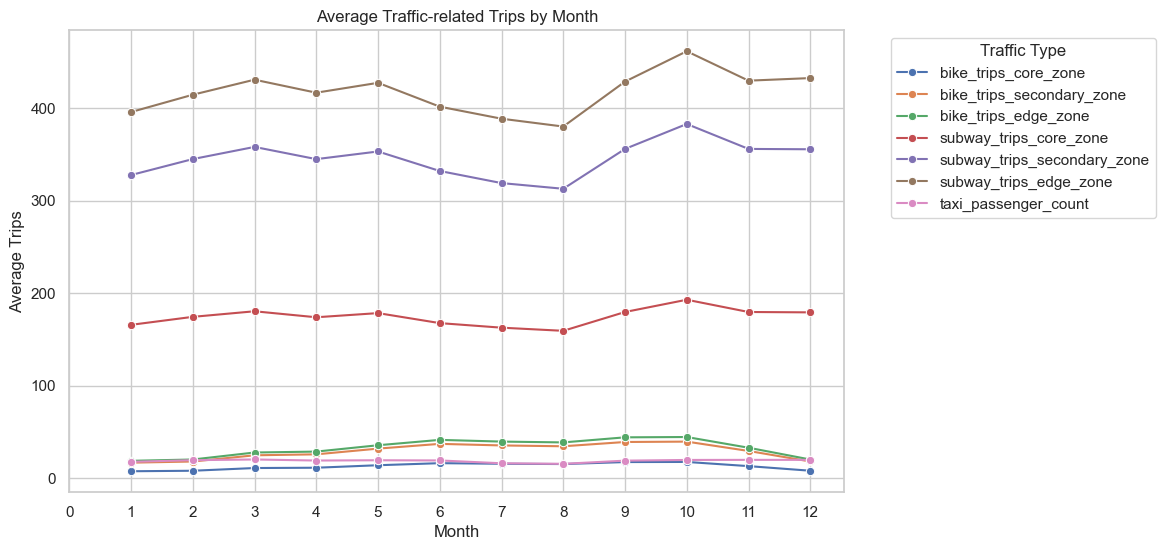

In [164]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in traffic_cols:
    monthly_avg = new_buffer_df.groupby('month', observed=False)[col].mean()
    sns.lineplot(
        x=monthly_avg.index,
        y=monthly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Traffic-related Trips by Month')
plt.xlabel('Month')
plt.ylabel('Average Trips')
plt.xticks(range(0, 13))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

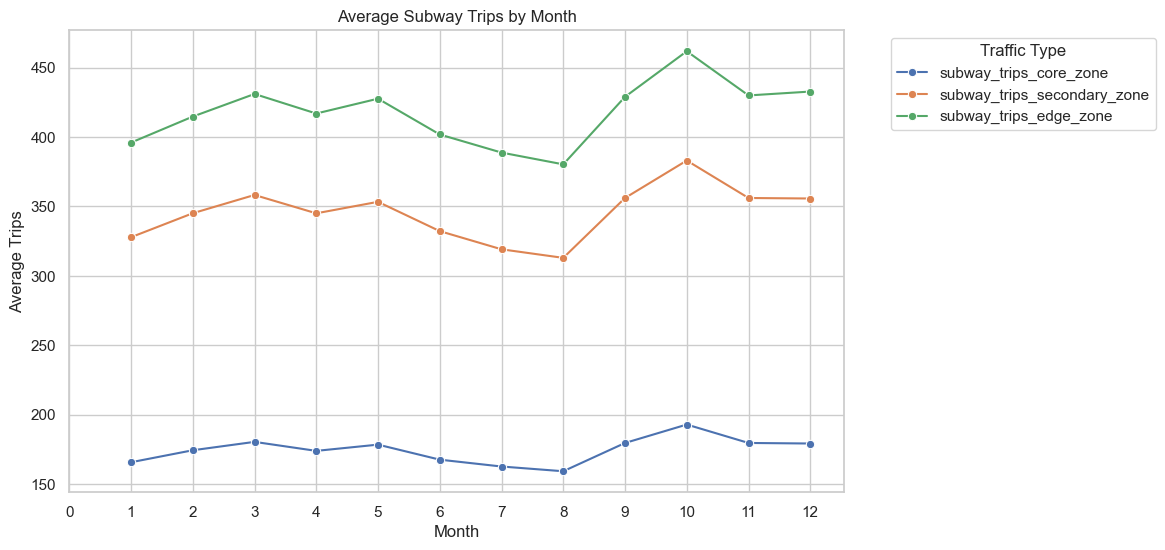

In [166]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone']:
    monthly_avg = new_buffer_df.groupby('month', observed=False)[col].mean()
    sns.lineplot(
        x=monthly_avg.index,
        y=monthly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Subway Trips by Month')
plt.xlabel('Month')
plt.ylabel('Average Trips')
plt.xticks(range(0, 13))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

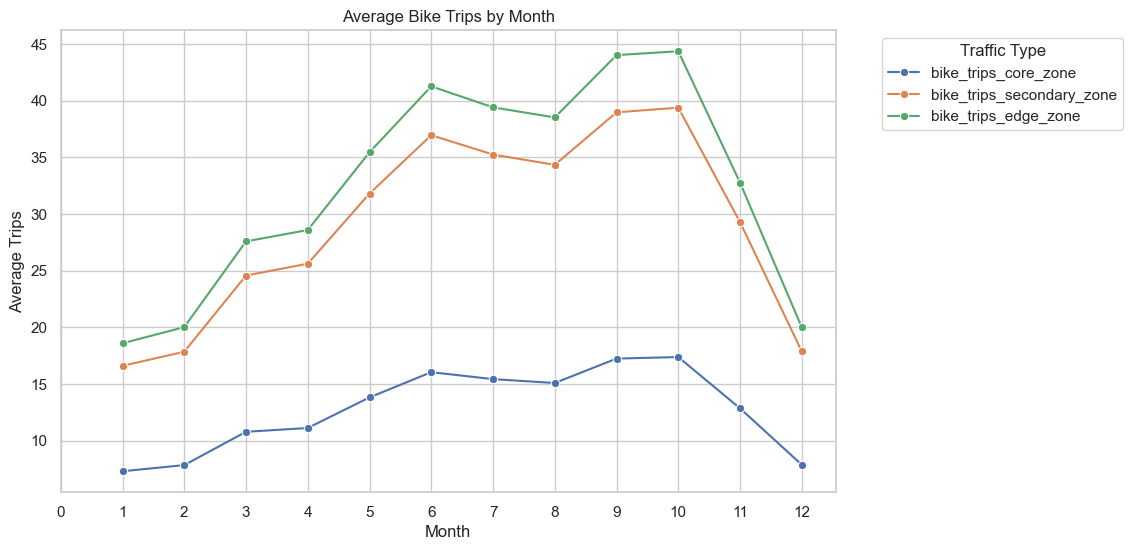

In [167]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone']:
    monthly_avg = new_buffer_df.groupby('month', observed=False)[col].mean()
    sns.lineplot(
        x=monthly_avg.index,
        y=monthly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Bike Trips by Month')
plt.xlabel('Month')
plt.ylabel('Average Trips')
plt.xticks(range(0, 13))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

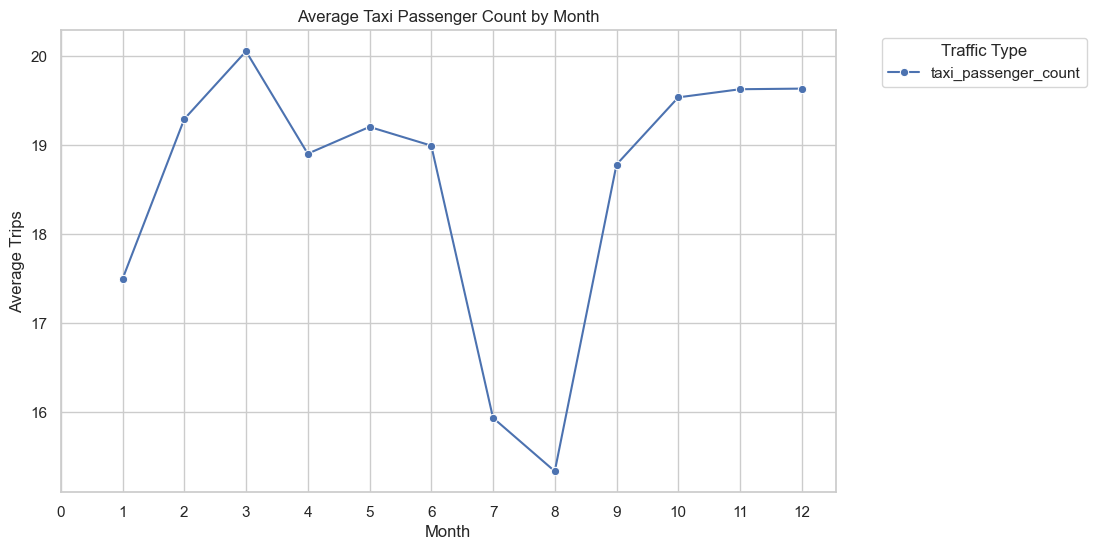

In [168]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))


for col in ['taxi_passenger_count']:
    monthly_avg = new_buffer_df.groupby('month', observed=False)[col].mean()
    sns.lineplot(
        x=monthly_avg.index,
        y=monthly_avg.values,
        marker='o',
        label=col
    )

plt.title('Average Taxi Passenger Count by Month')
plt.xlabel('Month')
plt.ylabel('Average Trips')
plt.xticks(range(0, 13))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

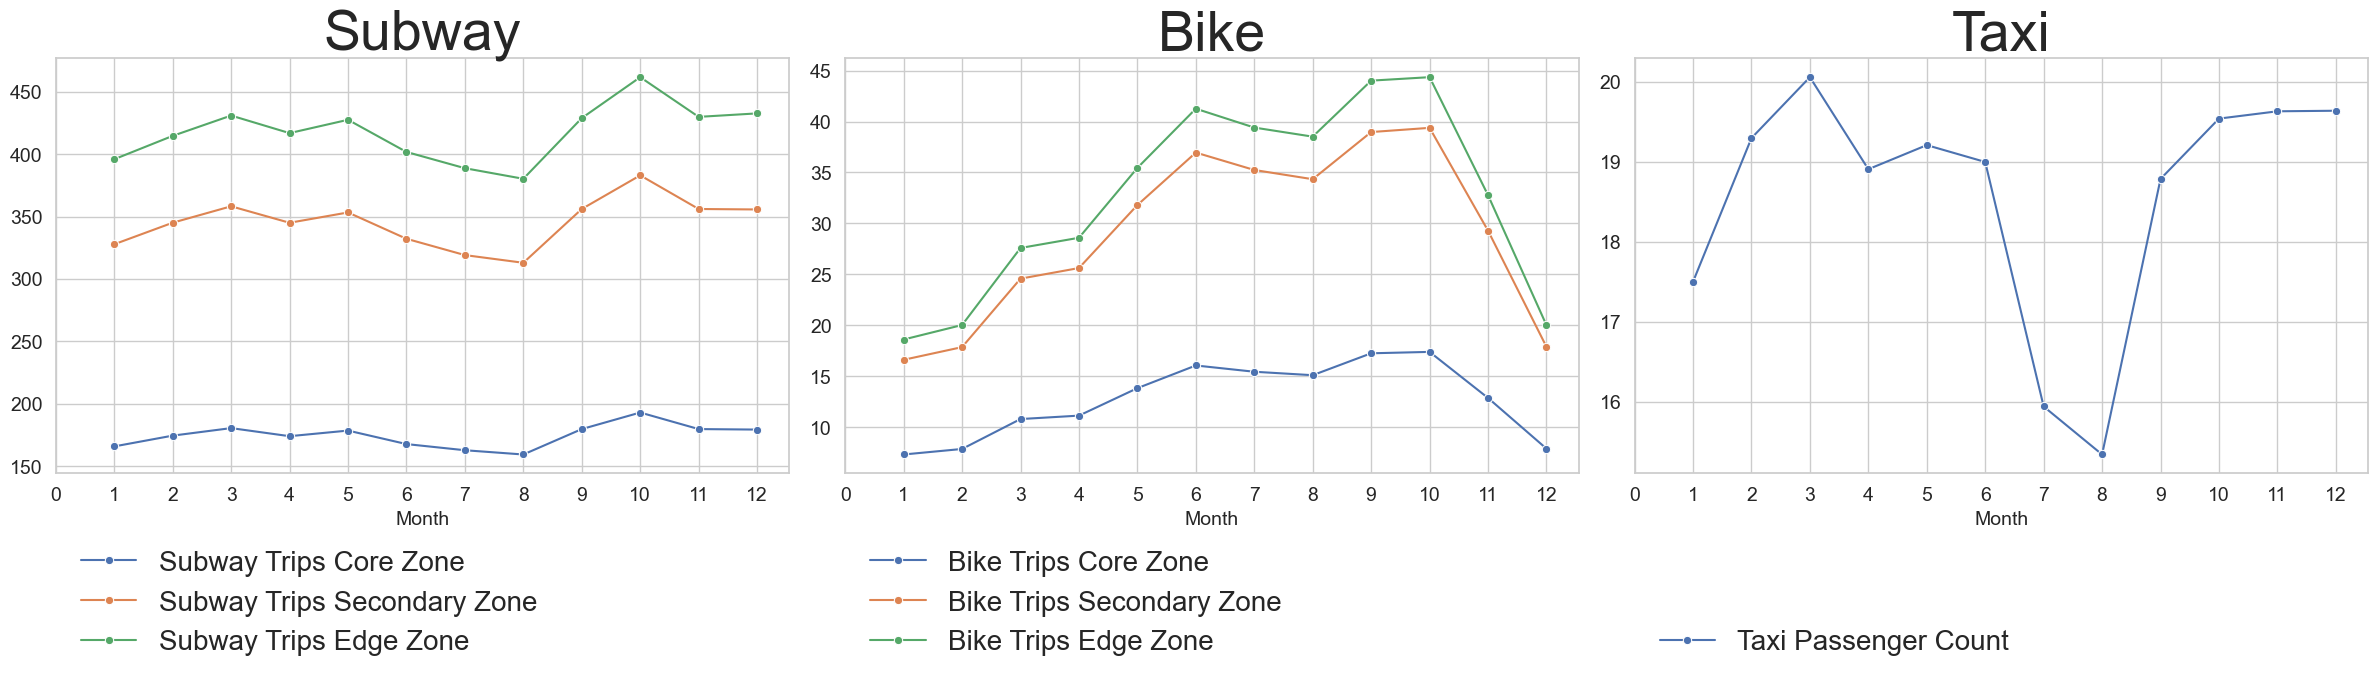

In [67]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

zone_mapping = {
    'Subway': ['subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone'],
    'Bike': ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone'],
    'Taxi': ['taxi_passenger_count']
}

for i, (mode, cols) in enumerate(zone_mapping.items()):
    ax = axes[i]
    for col in cols:
        monthly_avg = new_buffer_df.groupby('month', observed=False)[col].mean()
        sns.lineplot(
            x=monthly_avg.index,
            y=monthly_avg.values,
            marker='o',
            label=col.replace('_', ' ').title(),
            ax=ax
        )
    ax.set_title(mode, fontsize=40)
    ax.set_xlabel('Month', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(range(0, 13))
    ax.legend(
        loc='lower left',
        bbox_to_anchor=(0, -0.5),
        frameon=False,
        ncol=1,
        fontsize=20,
        )

plt.tight_layout()
plt.savefig('traffic_by_month.png', dpi=300, bbox_inches='tight')
plt.show()

### Daily
- Subway trips are consistently the lowest on weekends, with a clear increase during weekdays, reflecting commuting patterns typical of office workers.
- Bike usage shows a noticeable drop on Sundays, likely because many people treat Sunday as a rest day with less mobility demand.
- Taxi usage peaks on Saturdays, drops on Sundays, and hits the lowest point on Mondays. This pattern might be related to people going out more for leisure on Saturdays, followed by reduced mobility on Sundays, and lower demand on Mondays as people return to regular routines.

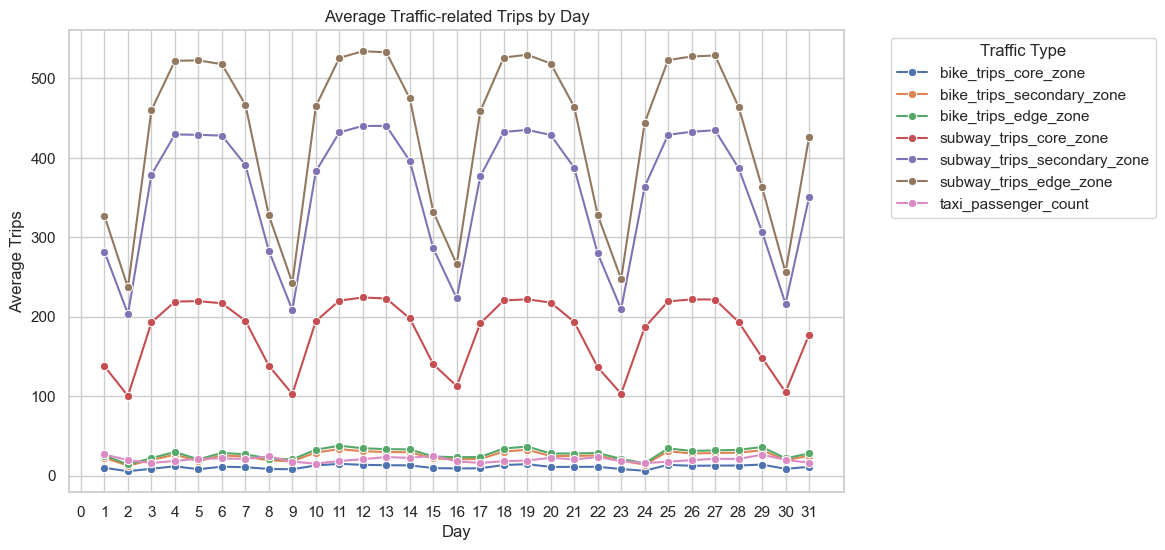

In [143]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in traffic_cols:
    daily_avg = march_25.groupby('day', observed=False)[col].mean()
    sns.lineplot(
        x=daily_avg.index,
        y=daily_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Traffic-related Trips by Day')
plt.xlabel('Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 32))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

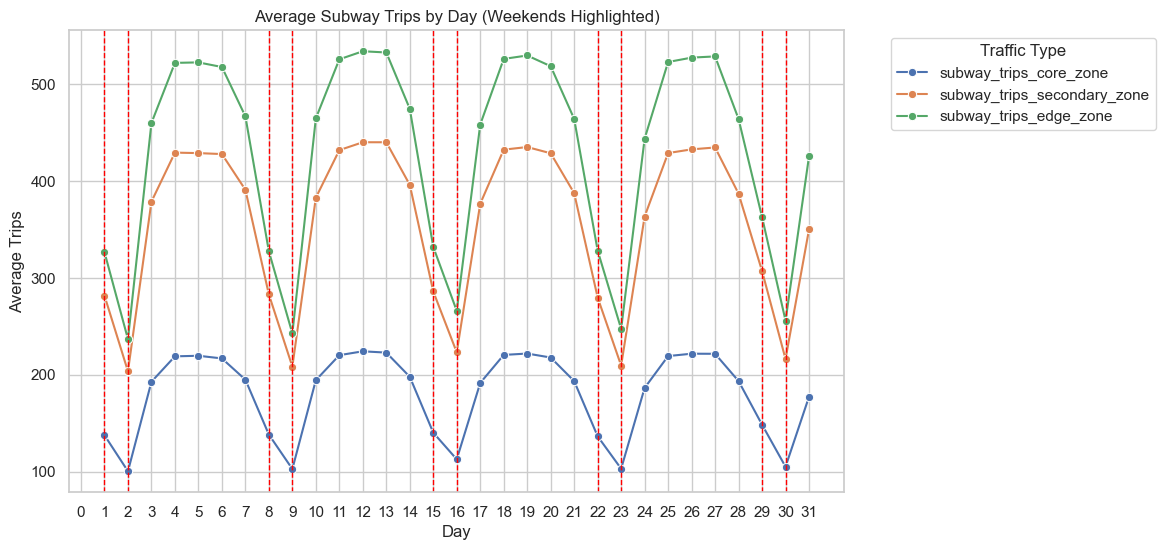

In [148]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone']:
    daily_avg = march_25.groupby('day', observed=False)[col].mean()
    sns.lineplot(
        x=daily_avg.index,
        y=daily_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

weekends = march_25[march_25['is_weekend'] == True][['day', 'is_weekend']].drop_duplicates()['day'].to_list()
for day in weekends:
    plt.axvline(x=day, color='red', linestyle='--', linewidth=1)
    
plt.title('Average Subway Trips by Day (Weekends Highlighted)')
plt.xlabel('Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 32))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

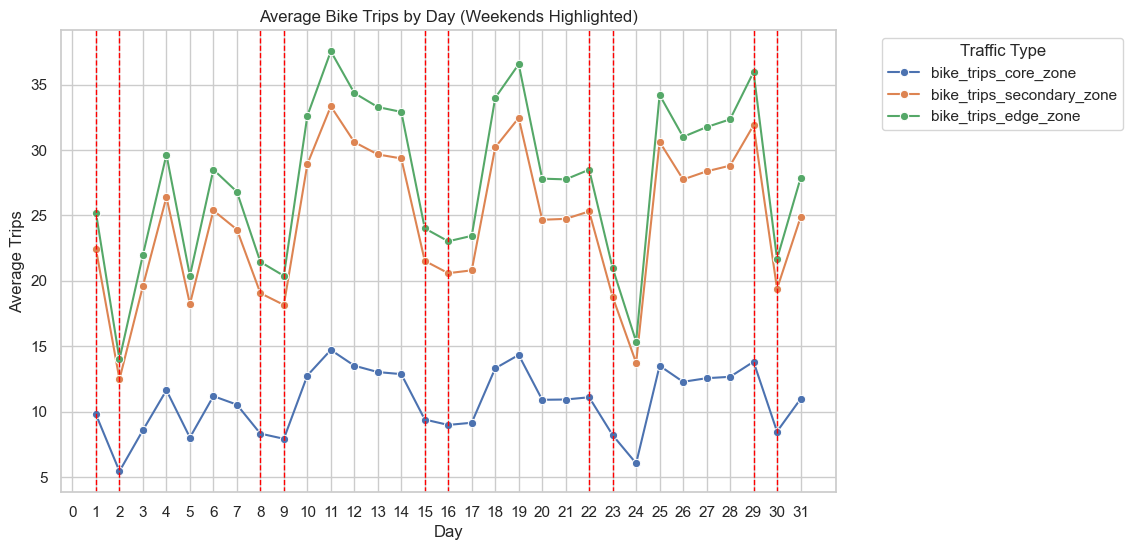

In [145]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone']:
    daily_avg = march_25.groupby('day', observed=False)[col].mean()
    sns.lineplot(
        x=daily_avg.index,
        y=daily_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

weekends = march_25[march_25['is_weekend'] == True][['day', 'is_weekend']].drop_duplicates()['day'].to_list()
for day in weekends:
    plt.axvline(x=day, color='red', linestyle='--', linewidth=1)
    
plt.title('Average Bike Trips by Day (Weekends Highlighted)')
plt.xlabel('Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 32))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

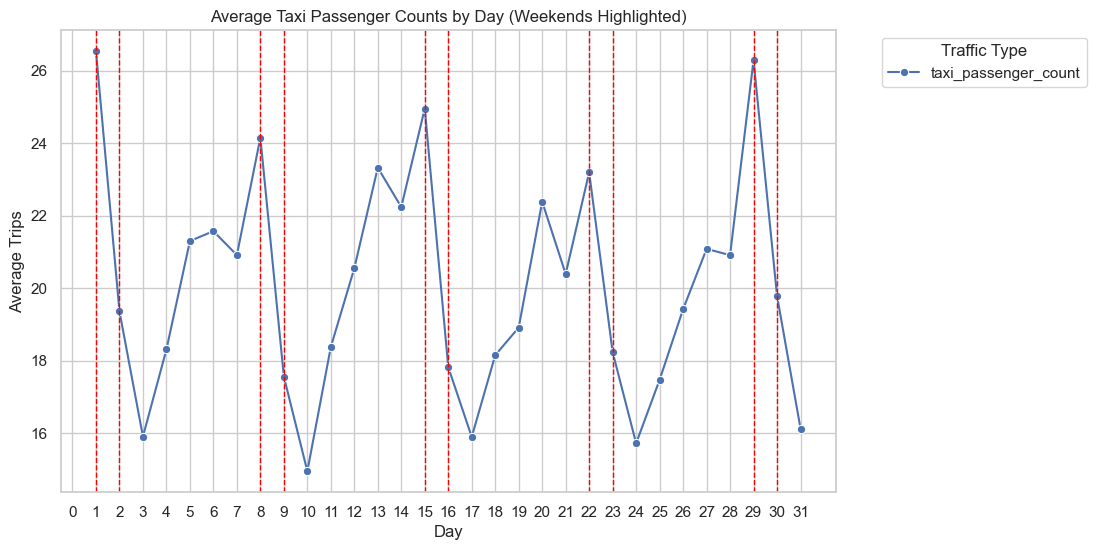

In [147]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['taxi_passenger_count']:
    daily_avg = march_25.groupby('day', observed=False)[col].mean()
    sns.lineplot(
        x=daily_avg.index,
        y=daily_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

weekends = march_25[march_25['is_weekend'] == True][['day', 'is_weekend']].drop_duplicates()['day'].to_list()
for day in weekends:
    plt.axvline(x=day, color='red', linestyle='--', linewidth=1)
    
plt.title('Average Taxi Passenger Counts by Day (Weekends Highlighted)')
plt.xlabel('Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 32))
plt.legend(title='Traffic Type', bbox_to_anchor=(1.05, 1), loc='upper left')
plt.show()

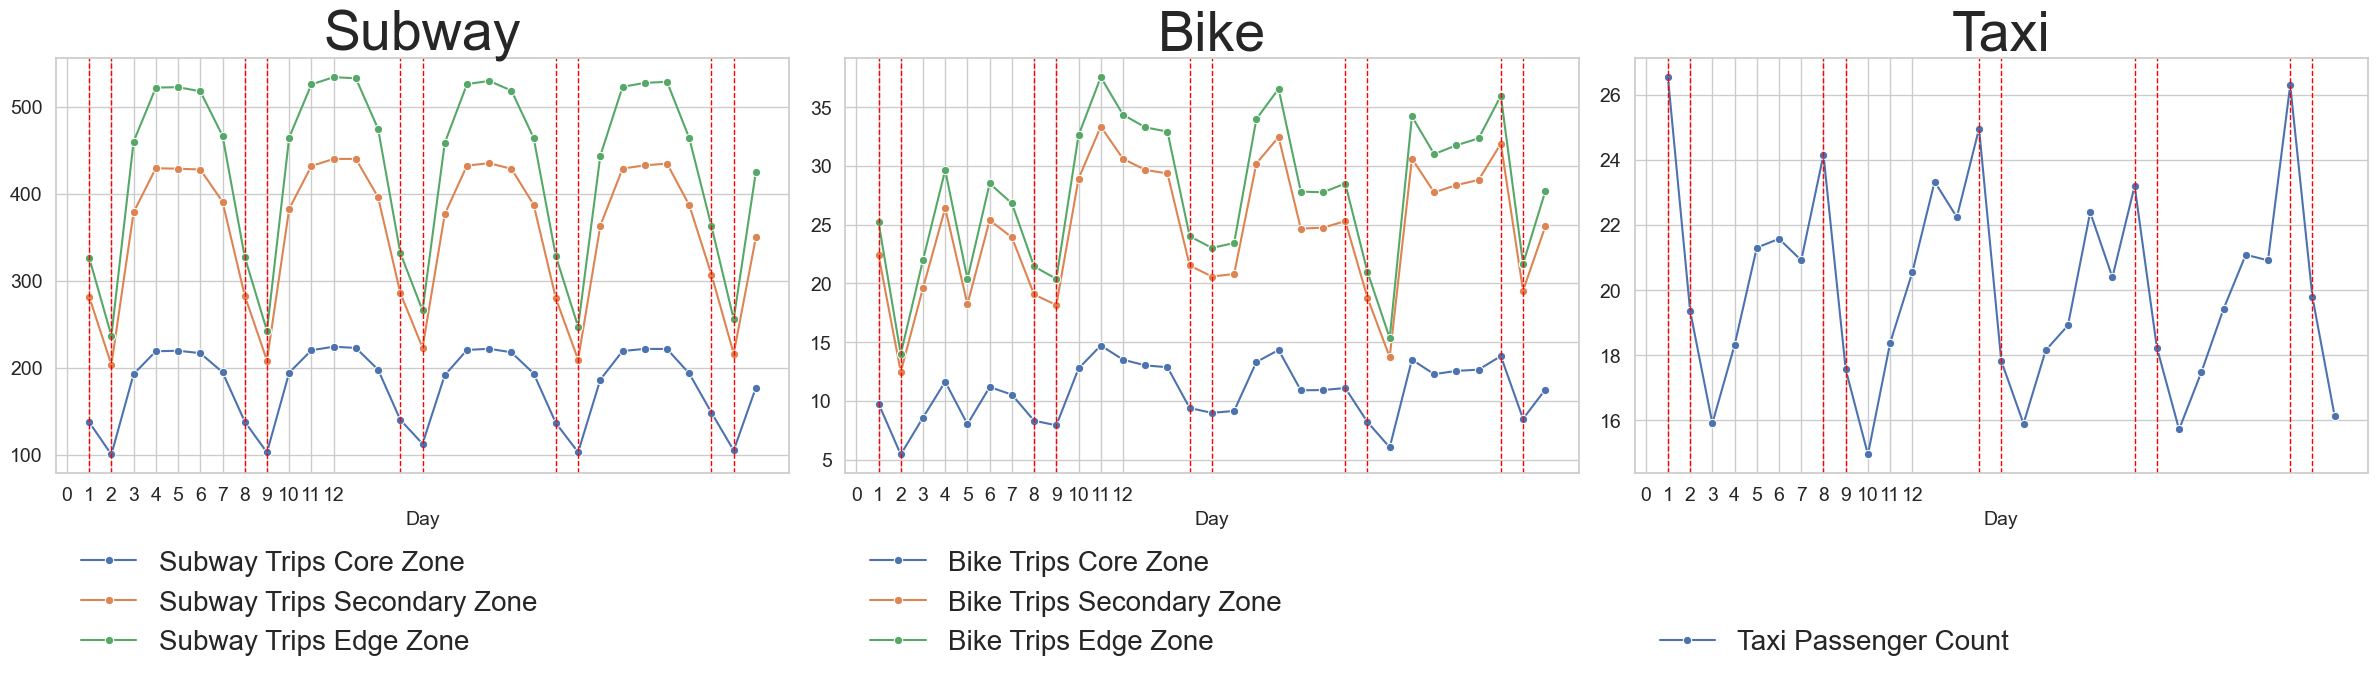

In [75]:
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")
plt.rcParams.update({'font.size': 14})
fig, axes = plt.subplots(1, 3, figsize=(24, 8))

zone_mapping = {
    'Subway': ['subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone'],
    'Bike': ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone'],
    'Taxi': ['taxi_passenger_count']
}

for i, (mode, cols) in enumerate(zone_mapping.items()):
    ax = axes[i]
    for col in cols:
        daily_avg = march_25.groupby('day', observed=False)[col].mean()
        sns.lineplot(
            x=daily_avg.index,
            y=daily_avg.values,
            marker='o',
            label=col.replace('_', ' ').title(),
            ax=ax
        )
    ax.set_title(mode, fontsize=40)
    ax.set_xlabel('Day', fontsize=14)
    ax.tick_params(axis='both', which='major', labelsize=14)
    ax.set_xticks(range(0, 13))
    ax.legend(
        loc='lower left',
        bbox_to_anchor=(0, -0.5),
        frameon=False,
        ncol=1,
        fontsize=20,
        )

    weekends = march_25[march_25['is_weekend'] == True]['day'].drop_duplicates().tolist()
    for day in weekends:
        ax.axvline(x=day, color='red', linestyle='--', linewidth=1)

plt.tight_layout()
plt.savefig('traffic_by_day.png', dpi=300, bbox_inches='tight')
plt.show()

### Hourly
- Subway data shows clear peaks during 7–8 AM and 4–5 PM, which likely corresponds to typical commuting hours. This pattern suggests that subway usage is primarily driven by work-related travel. The slight shift compared to other modes may be explained by the nature of subway commuting—longer distances requiring earlier departure times, and the data only records boarding times.
- Bike trips peak between 8–9 AM and 4–6 PM, which also aligns with commuting patterns. The slight delay compared to subway usage might reflect the nature of bike trips being more localized and flexible, often used for shorter distances or last-mile connections. The evening peak extending to 6 PM may also capture additional usage related to post-work activities such as dining or errands.
- Taxi usage reaches its lowest point around 4–5 AM and gradually increases throughout the day, peaking at 6–7 PM. This indicates higher demand for taxis during daytime hours, particularly around typical commuting and dinner times, reflecting both business and personal travel needs.

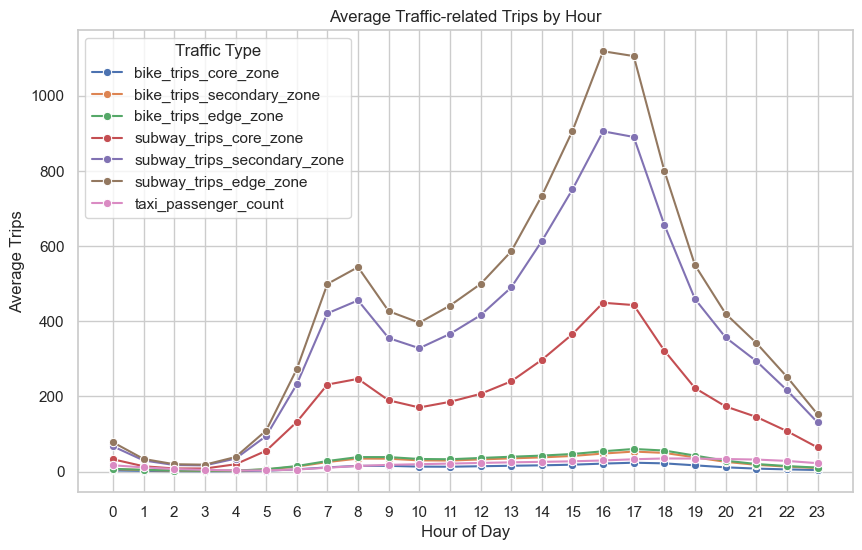

In [65]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in traffic_cols:
    hourly_avg = march_25.groupby('hour', observed=False)[col].mean()
    sns.lineplot(
        x=hourly_avg.index,
        y=hourly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Traffic-related Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 24))
plt.legend(title='Traffic Type')  # 自動用上面 label
plt.show()

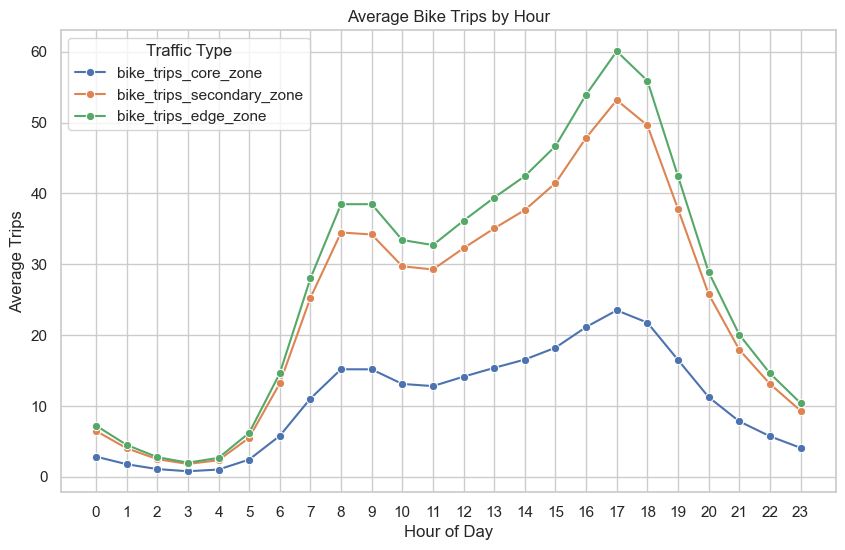

In [60]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone']:
    hourly_avg = march_25.groupby('hour', observed=False)[col].mean()
    sns.lineplot(
        x=hourly_avg.index,
        y=hourly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Bike Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 24))
plt.legend(title='Traffic Type')  # 自動用上面 label
plt.show()

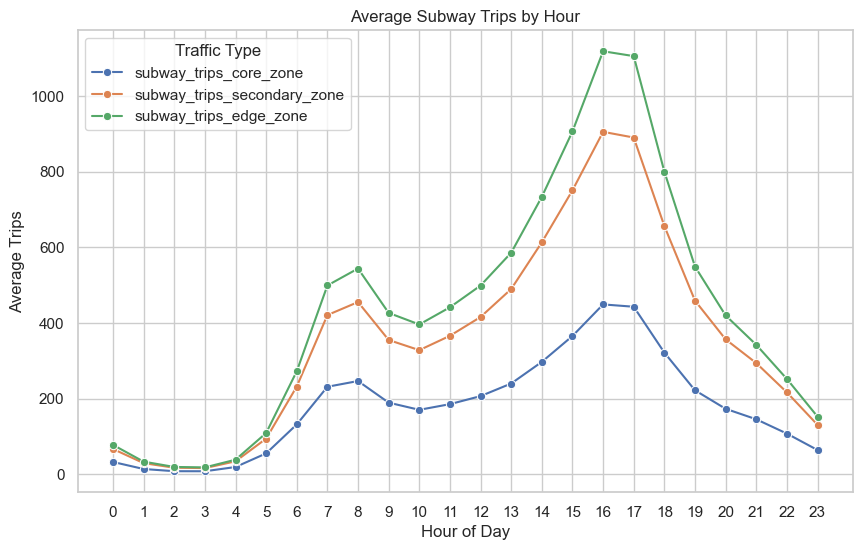

In [58]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone']:
    hourly_avg = march_25.groupby('hour', observed=False)[col].mean()
    sns.lineplot(
        x=hourly_avg.index,
        y=hourly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Average Subway Trips by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 24))
plt.legend(title='Traffic Type')  # 自動用上面 label
plt.show()

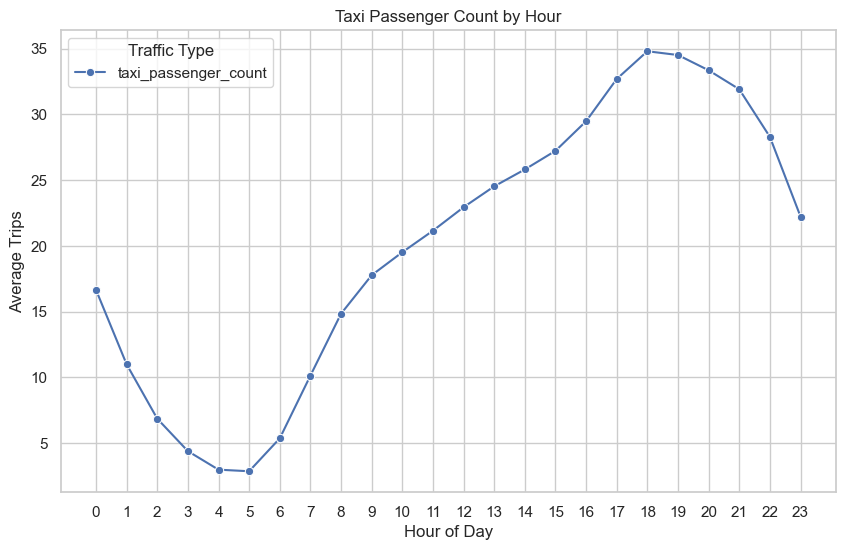

In [59]:
sns.set(style="whitegrid")

plt.figure(figsize=(10, 6))

for col in ['taxi_passenger_count']:
    hourly_avg = march_25.groupby('hour', observed=False)[col].mean()
    sns.lineplot(
        x=hourly_avg.index,
        y=hourly_avg.values,
        marker='o',
        label=col  # 加這個 legend 就會自動有了
    )

plt.title('Taxi Passenger Count by Hour')
plt.xlabel('Hour of Day')
plt.ylabel('Average Trips')
plt.xticks(range(0, 24))
plt.legend(title='Traffic Type')  # 自動用上面 label
plt.show()

## Spatial Analysis


### Traffic-related columns
- Since the previous analysis indicates that 5 PM is the busiest time of day, this time period was selected to further explore the spatial distribution of busyness across grids.
- The heatmaps of the average traffic-related indicators at 5 PM reveal that Lower Manhattan is consistently busier than Upper Manhattan. This pattern is observed across all modes of transportation, including bike, subway, and taxi usage, indicating a clear concentration of activity in the southern part of the city during peak hours.

In [27]:
target_time = march_25[march_25['hour'] == 17]
traffic_by_grid = target_time.groupby(['grid_id'], observed=False)[traffic_cols].mean().reset_index()
traffic_by_grid = traffic_by_grid.merge(target_time[['grid_id', 'geometry']].drop_duplicates(), on='grid_id')
traffic_by_grid = gpd.GeoDataFrame(
    traffic_by_grid,
    geometry='geometry',
    crs="EPSG:4326"
)
traffic_by_grid.info()

<class 'geopandas.geodataframe.GeoDataFrame'>
RangeIndex: 1140 entries, 0 to 1139
Data columns (total 9 columns):
 #   Column                       Non-Null Count  Dtype   
---  ------                       --------------  -----   
 0   grid_id                      1140 non-null   category
 1   bike_trips_core_zone         1140 non-null   float64 
 2   bike_trips_secondary_zone    1140 non-null   float64 
 3   bike_trips_edge_zone         1140 non-null   float64 
 4   subway_trips_core_zone       1140 non-null   float64 
 5   subway_trips_secondary_zone  1140 non-null   float64 
 6   subway_trips_edge_zone       1140 non-null   float64 
 7   taxi_passenger_count         1140 non-null   float64 
 8   geometry                     1140 non-null   geometry
dtypes: category(1), float64(7), geometry(1)
memory usage: 114.8 KB


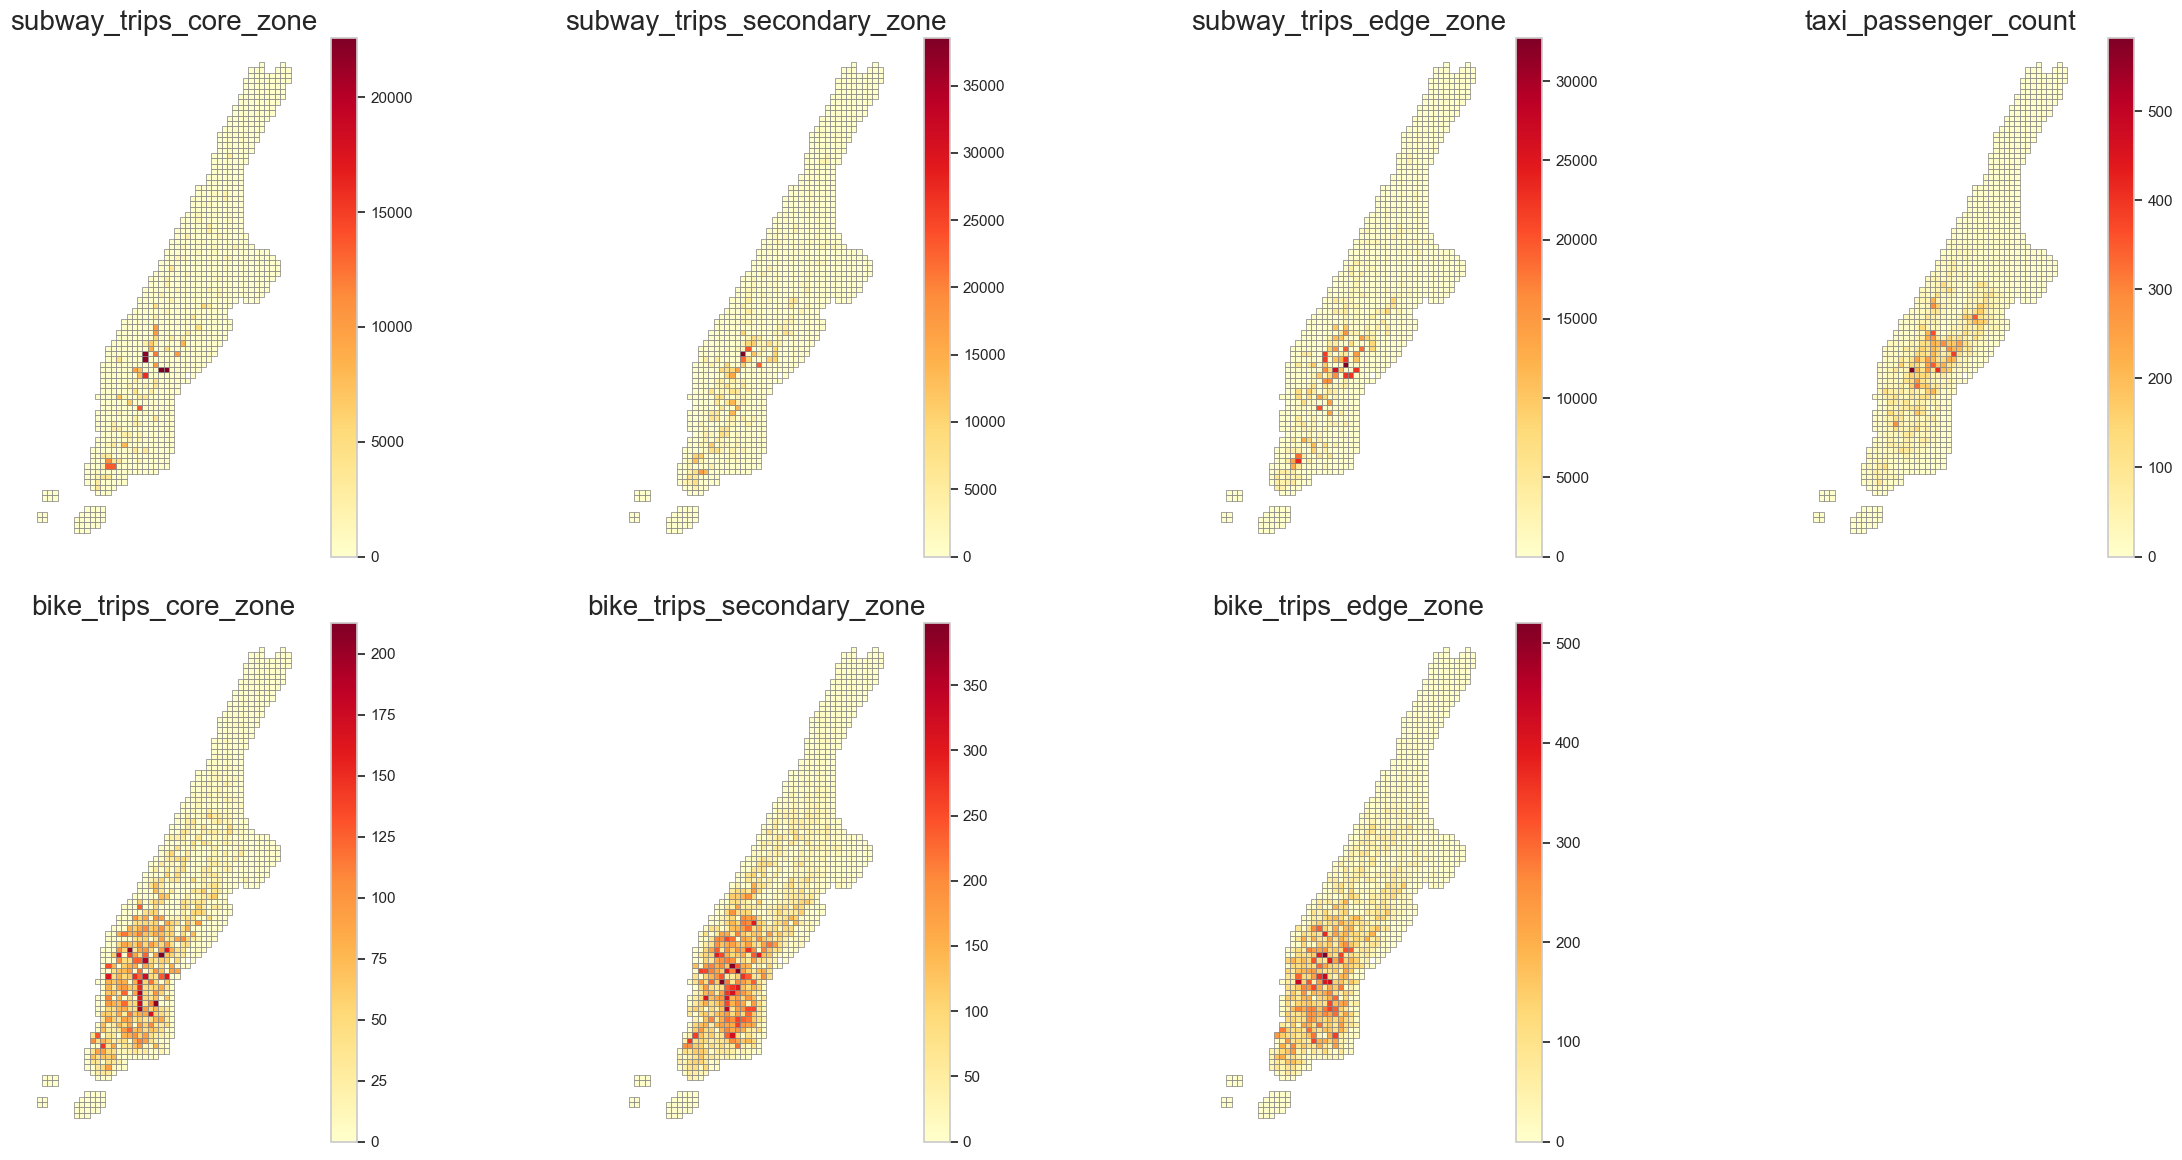

In [73]:
traffic_cols = [
    'subway_trips_core_zone', 'subway_trips_secondary_zone', 'subway_trips_edge_zone', 'taxi_passenger_count',
    'bike_trips_core_zone', 'bike_trips_secondary_zone', 'bike_trips_edge_zone',
]

plt.rcParams.update({'font.size': 20})
fig, axes = plt.subplots(2, 4, figsize=(24, 12))

axes = axes.flatten()
for i, col in enumerate(traffic_cols):
    traffic_by_grid.plot(
        column=col,
        cmap='YlOrRd',
        linewidth=0.5,
        edgecolor='grey',
        legend=True,
        ax=axes[i]
    )
    axes[i].set_title(col, fontsize=20)
    axes[i].axis('off')
    i += 1

for j in range(len(traffic_cols), len(axes)):
    fig.delaxes(axes[j])
    
plt.tight_layout()
plt.savefig('traffic_by_grid.png', dpi=300, bbox_inches='tight')
plt.show()

### Population
The population distribution visualized at the grid level aligns with the [2020 Census Results for New York City](https://www.nyc.gov/assets/planning/download/pdf/planning-level/nyc-population/census2020/dcp_2020-census-briefing-booklet-1.pdf). The spatial patterns observed—such as higher residential density in Uptown and parts of Upper Manhattan, and lower density in Central Park, Midtown, and Downtown commercial districts—are consistent with known demographic characteristics. This confirms that the dataset, after applying grid-cell mapping, shows no significant anomalies when compared to the official census data.

<Figure size 1000x600 with 0 Axes>

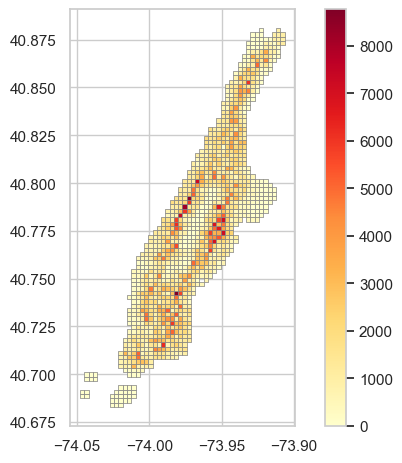

In [158]:
plt.figure(figsize=(10, 6))

population_by_grid = march_25[['grid_id', 'population', 'geometry']].drop_duplicates()

population_by_grid.plot(
        column='population',
        cmap='YlOrRd',
        linewidth=0.5,
        edgecolor='grey',
        legend=True    )
plt.tight_layout()
plt.show()

### Restuarant Count
The spatial distribution of restaurants closely resembles the patterns observed in the previous traffic-related analyses, with a clear concentration in Lower Manhattan. Additionally, the cluster of restaurants in Upper Manhattan aligns with the areas of higher residential population density. This suggests a strong correlation between restaurant locations and population-dense neighborhoods.

<Figure size 1000x600 with 0 Axes>

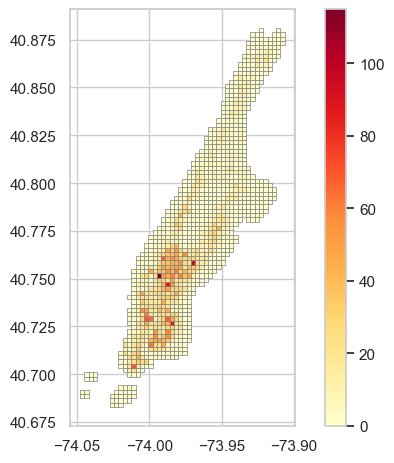

In [160]:
plt.figure(figsize=(10, 6))

restaurant_by_grid = march_25[['grid_id', 'restaurant_count', 'geometry']].drop_duplicates()

restaurant_by_grid.plot(
        column='restaurant_count',
        cmap='YlOrRd',
        linewidth=0.5,
        edgecolor='grey',
        legend=True
)
plt.tight_layout()
plt.show()

In [ ]:
for col in busyness_percentile_cols:
    combined_df[f'{col}_level'] = convert_percentile_to_level(combined_df[col])

In [ ]:
fig, axes = plt.subplots(8, 2, figsize=(18, 36))
i = 0
for col in busyness_percentile_cols:    
    plot_busyness_percentile_map(combined_df, '2024-05-01', 12, f'{col}_level', ax=axes[i, 0])
    plot_busyness_percentile_map(combined_df, '2024-05-01', 3, f'{col}_level', ax=axes[i, 1])
    i += 1

plt.tight_layout()
plt.show()

In [ ]:
lgbm_model = lgb.LGBMClassifier(
    objective='multiclass',
    num_class=5,
    learning_rate=0.1,
    num_leaves=64,
    n_estimators=100,
    random_state=42
)

In [ ]:
selected_percentile_cols = ['busyness_zscore_avg_percentile', 
                            'busyness_zscore_weighted_percentile', 
                            'busyness_percentile']

for col in selected_percentile_cols:
    print("===")
    print(col)
    y_lgbm = combined_df[f'{col}_level']
    y_lgbm = y_lgbm.astype(int) - 1
    
    predict_sample_dataset(model=lgbm_model,
                       input_X=X_lgbm,
                       input_y=y_lgbm,
                       sample_size=1000000,
                       y_type='categorical',
                       is_lgbm=True, 
                       eval_metric='multi_logloss')